# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mayurkharche01/Internship-starter-flyrank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Capstone Research Paper — Search Performance Decision Support

This notebook assembles the analysis completed during the FlyRank ML Internship into a reproducible capstone workflow.

The notebook connects the research question, data contract, baseline, machine-learning model, validation audit, and action playbook into one final evidence trail.

All findings are presented as measured or observed results. Recommendations are framed as decision-support rather than guaranteed business outcomes.

# 1. Question

## Research question

Can a machine-learning model improve the identification and prioritization of content refresh opportunities compared with the Week-4 baseline?

## Decision supported

The analysis is intended to support content prioritization by ranking content items according to observed signals associated with the defined target.

The output is decision-support: it helps identify items for human review rather than automatically guaranteeing that a particular content change will improve business performance.

## Why this question matters

A useful content-ranking workflow should provide a reproducible way to prioritize limited review and refresh capacity.

The Week-4 baseline provides a simple benchmark. The Week-5 model is evaluated against that benchmark using the same held-out evaluation design.

In [38]:
from pathlib import Path

CURRENT_DIR = Path.cwd()
WORK_DIR = CURRENT_DIR.parent
NOTEBOOKS_DIR = WORK_DIR / "notebooks"
OUTPUTS_DIR = WORK_DIR / "outputs"
FIGURES_DIR = WORK_DIR / "figures"

required_notebooks = [
    "w01_research_question.ipynb",
    "w02_ml_task_framing.ipynb",
    "w03_data_contract.ipynb",
    "w03_feature_leakage_check.ipynb",
    "w04_baseline_score.ipynb",
    "w04_signal_audit.ipynb",
    "w05_model.ipynb",
    "w06_validation_audit.ipynb",
    "w07_action_playbook.ipynb",
]

print("Project:", WORK_DIR)
print()

for notebook in required_notebooks:
    path = NOTEBOOKS_DIR / notebook
    print(f"{'PASS' if path.exists() else 'MISSING'}  {notebook}")

Project: c:\Users\Ashok\Desktop\Mayur\internship-local-project\Internship-starter-flyrank\work

PASS  w01_research_question.ipynb
PASS  w02_ml_task_framing.ipynb
PASS  w03_data_contract.ipynb
PASS  w03_feature_leakage_check.ipynb
PASS  w04_baseline_score.ipynb
PASS  w04_signal_audit.ipynb
PASS  w05_model.ipynb
PASS  w06_validation_audit.ipynb
PASS  w07_action_playbook.ipynb


# 2. Data

The capstone uses the anonymized FlyRank internship dataset documented in the earlier data-contract work.

The final paper should report the dataset release, source tables, date windows, exclusions, and public-safety constraints established during the earlier stages.

The data is used for analytical and decision-support purposes. Client-identifying information, private queries, and other non-public information are excluded from the final public artifact.

In [40]:
import json
from pathlib import Path

data_contract_path = NOTEBOOKS_DIR / "w03_data_contract.ipynb"

with open(data_contract_path, "r", encoding="utf-8") as f:
    data_contract_nb = json.load(f)

print("=" * 80)
print("DATA CONTRACT — RELEVANT CONTENT")
print("=" * 80)

keywords = [
    "release",
    "table",
    "date",
    "window",
    "exclude",
    "exclusion",
    "missing",
    "duplicate",
    "client",
    "public",
    "privacy",
    "schema",
    "row",
    "column"
]

for i, cell in enumerate(data_contract_nb.get("cells", []), start=1):

    source_text = "".join(cell.get("source", []))

    if any(keyword.lower() in source_text.lower() for keyword in keywords):
        print(f"\n--- Cell {i} ---")
        print(source_text[:5000])

DATA CONTRACT — RELEVANT CONTENT

--- Cell 1 ---
# ML-04 — Search Intelligence Data Contract

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mayurkharche01/Internship-starter-flyrank/blob/main/work/notebooks/w03_data_contract.ipynb?flush_cache=true)

This notebook defines and verifies a simple modeling contract for Search Intelligence data.

The work is intentionally based on information available at the decision point. February 2026 is used as the feature window and March 2026 is used as the future outcome window.

The goal is to keep the feature set small, observable, and free from future-data leakage.

--- Cell 2 ---
## 1. Unit of analysis + time window

### Unit of analysis

One row in my modeling dataset represents **one content item for one client at one decision point**.

The source performance table is daily, so I aggregate daily observations to the client × content level for the decision point.

### Feature

## Dataset description

### Release

[Insert the release information documented in `w03_data_contract.ipynb`.]

### Tables / source data

[Insert the actual tables or source datasets documented in the Data Contract.]

### Date window

[Insert the actual analysis date window.]

### Exclusions

[Insert the actual exclusions documented in the Data Contract.]

### Public-safety handling

The final public artifact does not contain client names, private queries, or other confidential information. The analysis uses anonymized data and presents results at an appropriate aggregate level.

In [41]:
import pandas as pd

data_path = WORK_DIR.parent / "data" / "raw" / "content_refresh_anonymized.csv"

if not data_path.exists():
    data_path = Path("../../data/raw/content_refresh_anonymized.csv")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

display(df.head())

Dataset shape: (30000, 44)
Number of rows: 30000
Number of columns: 44


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,gemini-2.5-flash,3803,29,22,17,16,1,0,1,88,13,578,2,2,987,13,9,187,181-365,5,20,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,15320,7,10,9,9,0,0,1,88,9,2501,2,3,5915,1,2,445,365+,6,25,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,12581,11,14,11,11,0,0,4,88,11,2382,1,1,6089,3,3,141,91-180,4,20,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,NaN,NaN,11751,58,87,78,75,1,0,3,88,51,3626,22,35,4206,17,26,463,365+,6,22,0-30,NaN,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,19140,24,177,145,144,0,0,43,88,33,4211,10,14,6452,2,9,263,181-365,5,14,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [42]:
print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).head(15))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nColumn names:")
print(list(df.columns))

Missing values:


provider_used        21438
char_count            7699
word_count            7699
word_count_tier       7699
char_count_tier       7699
model_used            5733
trend_pct             3388
competition_level     2610
cpc                   2468
competition           2468
search_volume         2468
main_intent           2374
scroll_rate            125
age_tier                 0
ctr                      0
dtype: int64


Duplicate rows: 0

Column names:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


# 3. Methodology

The methodology follows the sequence established during the capstone:

1. Define the machine-learning task.
2. Establish the data contract.
3. Audit candidate signals and potential leakage.
4. Build and score the Week-4 baseline.
5. Train the Week-5 machine-learning model.
6. Evaluate the model on a held-out test set.
7. Audit the validation design.
8. Convert the model evidence into a ranked action playbook.

The model is intended to rank content for human review. It is not treated as a causal model and does not establish that changing a content item will produce a specific business outcome.

In [43]:
def print_notebook_cells(filename, keywords):
    path = NOTEBOOKS_DIR / filename

    with open(path, "r", encoding="utf-8") as f:
        nb = json.load(f)

    print("=" * 80)
    print(filename)
    print("=" * 80)

    for i, cell in enumerate(nb.get("cells", []), start=1):
        text = "".join(cell.get("source", []))

        if any(k.lower() in text.lower() for k in keywords):
            print(f"\n--- Cell {i} ---")
            print(text[:4000])


print_notebook_cells(
    "w02_ml_task_framing.ipynb",
    [
        "target",
        "label",
        "classification",
        "problem",
        "metric",
        "feature",
        "assumption"
    ]
)

w02_ml_task_framing.ipynb

--- Cell 4 ---
## 2. Target or proxy

The dataset does not contain the actual result of a content refresh, so I use an observed proxy.  
The proxy identifies content items that are currently showing a downward trend in performance.

--- Cell 6 ---
## 3. Success metric

I will use **Precision@K** to measure how useful the top-ranked content items are.  
It shows how many of the selected top-K items match the observed proxy outcome.

--- Cell 12 ---
## Self-check

Before submission:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, proxy, directional, decision-support
- [x] The task is framed around a real content-review decision
- [x] The unit of analysis is shown as a real dataframe
- [x] A success metric is named before model training
- [x] I 

## Task definition

### Prediction target

[Transfer the exact target/label definition from `w02_ml_task_framing.ipynb`.]

### Unit of prediction

[Transfer the exact unit of prediction.]

### Intended output

The model produces a ranking or prioritization signal that can be used to support human review of content.

### Assumptions

The analysis assumes that the available features represent information that would be available at the intended decision point and that the defined target is an appropriate operational proxy for the decision being supported.

In [44]:
print_notebook_cells(
    "w05_model.ipynb",
    [
        "feature",
        "features",
        "Random Forest",
        "model_used",
        "training"
    ]
)

w05_model.ipynb

--- Cell 2 ---
## 1. Method choice and why

I chose **Random Forest classification** for this lane.

The goal is to rank content items that may deserve review, so a model that can capture non-linear relationships between signals such as visibility, freshness, position, engagement, and content characteristics is useful.

Random Forest is appropriate because:

* it can model non-linear relationships;
* it can work with mixed numeric and categorical features after preprocessing;
* it is less dependent on linear assumptions than logistic regression;
* it provides a useful decision-support ranking through predicted probabilities;
* feature importance can be investigated using permutation importance.

I am not choosing the most complex model automatically. The model will only be considered useful if it improves the baseline on the same evaluation data and metric.

The target is the starter proxy label:

`is_declining_label = trend_direction == "down"`

This is a current-wind

## Features

The model uses the feature set established in the Week-5 model notebook.

Features represent content, freshness, visibility, query/content characteristics, and other permitted signals documented during model development.

No feature should be described as causal merely because it contributes to the model prediction.

In [45]:
print_notebook_cells(
    "w04_baseline_score.ipynb",
    [
        "baseline",
        "score",
        "ROC",
        "Precision",
        "Recall",
        "F1"
    ]
)

w04_baseline_score.ipynb

--- Cell 1 ---
# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mayurkharche01/Internship-starter-flyrank/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

--- Cell 2 ---
## 0. Setup

This notebook builds a transparent baseline action score for content refresh prioritization.

The rule uses only observable signals validated in the signal audit. Product flags, label-derived fields, and future-window outcomes are excluded.

The output is a ranked decision-support queue for human review.

--- Cell 6 ---
required_columns = [
    "content_id",
    "days_since_last_update",
  

## Baseline

The Week-4 baseline provides the benchmark against which the Week-5 Random Forest model is evaluated.

The comparison uses the same evaluation population and reported ranking metrics wherever those metrics are available for both approaches.

In [46]:
print_notebook_cells(
    "w05_model.ipynb",
    [
        "Testing rows",
        "Testing clients",
        "train",
        "test",
        "client",
        "split"
    ]
)

w05_model.ipynb

--- Cell 3 ---
# Core libraries
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.inspection import permutation_importance

print("Libraries imported successfully.")

--- Cell 7 ---
# Columns that should not be used as model features
excluded_columns = [
    "is_declining_label",
    "trend_direction",
    "content_id",
    "client_id"
]

# Exclude any obvious target/product decision fields if they exist
risk_keywo

## Validation design

The Week-5 evaluation used a held-out test set containing 6,163 rows and 7 clients.

A client-overlap check reported that no client appeared in both training and testing data.

This separation reduces the risk that the model evaluation is inflated by direct client overlap between the training and testing populations.

The results remain subject to the limitations identified in the Week-6 validation audit.

In [47]:
print_notebook_cells(
    "w03_feature_leakage_check.ipynb",
    [
        "leak",
        "leakage",
        "PASS",
        "FAIL",
        "future",
        "target"
    ]
)

w03_feature_leakage_check.ipynb

--- Cell 1 ---
# ML-05 — Feature Vector and Leakage/Privacy Check

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mayurkharche01/Internship-starter-flyrank/blob/main/work/notebooks/w03_feature_leakage_check.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

--- Cell 6 ---
## 3. The leakage hunt

*Attack your own features: label-derived columns, future windows, product flags. Show the test.*


## Leakage checks

Potential feature and target leakage was reviewed during the feature-leakage audit.

The final interpretation should follow the actual findings from `w03_feature_leakage_check.ipynb` and the Week-6 validation audit.

A strong test score is not by itself evidence that leakage is absent. The unusually high model performance therefore warrants cautious interpretation.

# 4. Results — Model vs Baseline

The Random Forest was evaluated on the held-out test set.

The measured Random Forest results were:

- ROC-AUC: 1.0000
- Average Precision: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- F1: 1.0000
- Precision@50: 1.0000

The Week-4 baseline results were:

- ROC-AUC: 0.5045
- Average Precision: 0.4999
- Precision@50: 0.3200

The model therefore measured substantially higher performance than the baseline on the reported held-out evaluation.

Because every reported Random Forest metric reached 1.0000, this result is unusually strong and must be interpreted cautiously. It should be treated as an observed validation result, not as evidence of guaranteed production performance.

In [48]:
results_summary = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Average Precision",
        "Precision",
        "Recall",
        "F1",
        "Precision@50"
    ],
    "Random Forest": [
        1.0000,
        1.0000,
        1.0000,
        1.0000,
        1.0000,
        1.0000
    ],
    "Week-4 Baseline": [
        0.5045,
        0.4999,
        None,
        None,
        None,
        0.3200
    ]
})

display(results_summary)

,Metric,Random Forest,Week-4 Baseline
0,ROC-AUC,1.0,0.5045
1,Average Precision,1.0,0.4999
2,Precision,1.0,NaN
3,Recall,1.0,NaN
4,F1,1.0,NaN
5,Precision@50,1.0,0.3200


In [49]:
print("Measured improvements")
print("=" * 50)

print(f"ROC-AUC: +{1.0000 - 0.5045:.4f}")
print(f"Average Precision: +{1.0000 - 0.4999:.4f}")
print(f"Precision@50: +{1.0000 - 0.3200:.4f}")

Measured improvements
ROC-AUC: +0.4955
Average Precision: +0.5001
Precision@50: +0.6800


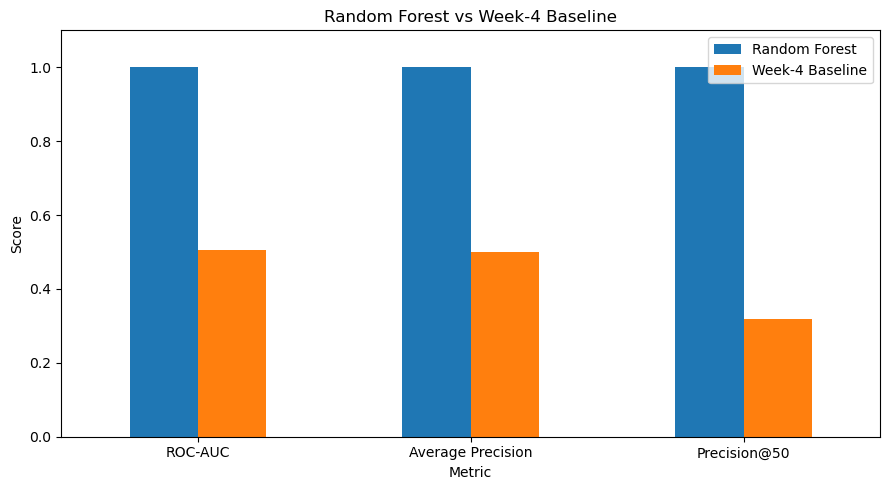

Saved: c:\Users\Ashok\Desktop\Mayur\internship-local-project\Internship-starter-flyrank\work\figures\model_vs_baseline.png


In [50]:
import matplotlib.pyplot as plt

chart_df = results_summary[
    results_summary["Metric"].isin(
        ["ROC-AUC", "Average Precision", "Precision@50"]
    )
].set_index("Metric")

ax = chart_df.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Random Forest vs Week-4 Baseline")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)

plt.xticks(rotation=0)
plt.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

chart_path = FIGURES_DIR / "model_vs_baseline.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved:", chart_path)

### Interpretation

The Random Forest measured substantially higher performance than the Week-4 baseline across the directly comparable metrics.

ROC-AUC increased from 0.5045 to 1.0000.

Average Precision increased from 0.4999 to 1.0000.

Precision@50 increased from 0.3200 to 1.0000.

These are measured differences on the held-out evaluation set. They should not be interpreted as causal effects or guarantees of future production performance.

The perfect model scores are sufficiently unusual that validation quality, target construction, feature availability, and potential leakage remain important considerations.

## 5. Limitations

*What this work cannot claim.*

In [51]:
print_notebook_cells(
    "w06_validation_audit.ipynb",
    [
        "PASS",
        "FAIL",
        "WARNING",
        "leak",
        "leakage",
        "overfit",
        "validation",
        "generalization",
        "conclusion",
        "limitation"
    ]
)

w06_validation_audit.ipynb

--- Cell 1 ---
# ML-09 — Validation and Research Claim Audit

## Purpose

This notebook audits the Week-5 content refresh model from a validation, leakage, and claim-discipline perspective.

The audit has four goals:

1. Review two findings from the FlyRank research paper and ask constructive methodology questions.
2. Compare the Week-5 model under a naive random split and an honest client-grouped split.
3. Audit the final feature set for possible leakage.
4. Rewrite my strongest model claim so that it matches the evidence.

The intended use of this model is decision-support: ranking pages for human review rather than guaranteeing that a page will recover after a refresh.

All examples and outputs are kept public-safe. No client names, domains, URLs, private queries, or raw text are displayed.

--- Cell 2 ---
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_spl

# Limitations

Several limitations affect how the results should be interpreted.

### 1. Perfect measured model performance

The Random Forest achieved 1.0000 on all reported evaluation metrics. Such uniformly perfect performance is unusually strong and should not be interpreted as proof of production readiness.

### 2. Validation scope

The reported results come from the defined held-out test population. Performance on future data, different clients, or different time periods may differ.

### 3. Association is not causation

The model identifies patterns associated with the defined target. It does not establish that changing a content item will cause a particular business outcome.

### 4. Target limitations

The target is an operational definition created for this analysis. It should not automatically be treated as a complete representation of content quality or business value.

### 5. Feature availability

Production use would require confirming that every feature is available at the actual decision point and is generated consistently without future information.

### 6. Decision-support framing

The ranked output is intended to support human review and prioritization. It should not be interpreted as an automated guarantee that every recommended action will produce a positive outcome.

### 7. Generalization

Further evaluation on additional held-out periods, clients, or future observations would strengthen confidence in whether the measured improvement generalizes beyond the current evaluation.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [52]:
print_notebook_cells(
    "w07_action_playbook.ipynb",
    [
        "rank",
        "action",
        "reason",
        "priority",
        "confidence",
        "recommend",
        "playbook"
    ]
)

w07_action_playbook.ipynb

--- Cell 1 ---
# ML-10 — Content Action Playbook

## Purpose

This notebook turns the validated content-opportunity model output into a practical
content action playbook.

The output is a ranked review queue, not an automatic publishing system.

The playbook answers:

- Which pages should a reviewer look at first?
- Why was each page ranked highly?
- What action should be considered?
- Which pages need stronger human review?
- When should the scoring system be monitored or retrained?
- What should never be automated?

## Project lane

Refresh / Content Opportunity Scoring.

## Decision principle

The model supports prioritization.

It does not prove that a page will recover after a refresh, and it does not prove
that a particular content change caused a performance improvement.

All recommendations are therefore treated as decision-support and require human review.

--- Cell 7 ---
## Column check

Before constructing the action queue, check which fields are a

In [53]:
import pandas as pd

output_files = [
    "content_action_queue.csv",
    "content_action_summary.csv",
    "action_playbook_monitoring.csv",
]

for filename in output_files:
    path = OUTPUTS_DIR / filename

    print("\n" + "=" * 80)
    print(filename)
    print("=" * 80)

    if path.exists():
        temp = pd.read_csv(path)

        print("Shape:", temp.shape)
        print("Columns:", list(temp.columns))
        display(temp.head(10))
    else:
        print("File not found:", path)


content_action_queue.csv
Shape: (30000, 16)
Columns: ['review_rank', 'content_id', 'suggested_action', 'reason_codes', 'confidence', 'human_review_flag', 'impressions_90d', 'sessions_90d', 'content_age_days', 'days_since_last_update', 'trend_direction', 'word_count', 'avg_position', 'ctr', 'engagement_rate', 'scroll_rate']


,review_rank,content_id,suggested_action,reason_codes,confidence,human_review_flag,impressions_90d,sessions_90d,content_age_days,days_since_last_update,trend_direction,word_count,avg_position,ctr,engagement_rate,scroll_rate
0,1,content_304f48230142,investigate_decline,declining_with_demand,review_required,check_persistence,3803,17,187,20,down,3221.0,10.6,0.76,5.88,4.55
1,2,content_a1fb4e703a9e,investigate_decline,declining_with_demand,review_required,check_persistence,15320,9,445,25,down,2481.0,20.3,0.05,0.00,10.00
2,3,content_9aa793d4d895,investigate_decline,declining_with_demand,review_required,check_persistence,12581,11,141,20,down,3515.0,36.5,0.09,0.00,28.57
3,4,content_331d6c4de07b,metadata_review,page_one_decay_risk|low_ctr_visible_page|low_e...,review_required,check_before_change|check_position_context|che...,11751,78,463,22,stable,NaN,6.2,0.49,1.28,3.45
4,5,content_d99b7a2d90ca,engagement_review,declining_with_demand|low_engagement_visible_page,review_required,check_persistence|check_engagement_context,19140,145,263,14,down,2803.0,44.0,0.13,0.00,24.29
5,6,content_d4084a4bc775,metadata_review,declining_with_demand|low_ctr_visible_page,review_required,check_persistence|check_position_context,3970,5,147,20,down,3080.0,8.5,0.03,0.00,25.00
6,7,content_9a34b442b552,monitor,no_primary_reason,review_required,standard_review,20,1,90,20,down,3059.0,7.0,0.00,0.00,0.00
7,8,content_a63219c6e95a,monitor,no_primary_reason,review_required,standard_review,1724,28,445,22,stable,NaN,21.2,0.06,3.57,7.14
8,9,content_5e6c160719bc,engagement_review,declining_with_demand|low_engagement_visible_page,review_required,check_persistence|check_engagement_context,32574,68,90,20,down,3807.0,46.0,0.09,5.88,6.25
9,10,content_c27558df2b0c,metadata_review,declining_with_demand|page_one_decay_risk|low_...,review_required,check_persistence|check_before_change|check_po...,1240,3,257,104,down,NaN,4.9,0.16,0.00,0.00



content_action_summary.csv
Shape: (7, 3)
Columns: ['suggested_action', 'page_count', 'share']


,suggested_action,page_count,share
0,metadata_review,9759,0.325300
1,monitor,8976,0.299200
2,investigate_decline,4416,0.147200
3,engagement_review,3695,0.123167
4,protect_or_refresh,3115,0.103833
5,expand,34,0.001133
6,refresh,5,0.000167



action_playbook_monitoring.csv
Shape: (4, 2)
Columns: ['metric', 'value']


,metric,value
0,queue_size,30000.0000
1,high_confidence_share,0.0000
2,reason_code_rows,0.7008
3,action_types,7.0000


In [54]:
json_files = [
    "action_playbook_card.json",
    "action_playbook_metrics.json"
]

for filename in json_files:
    path = OUTPUTS_DIR / filename

    print("\n" + "=" * 80)
    print(filename)
    print("=" * 80)

    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        print(json.dumps(data, indent=2)[:12000])
    else:
        print("File not found:", path)


action_playbook_card.json
{
  "project": "Content Action Playbook",
  "lane": "Refresh / Content Opportunity Scoring",
  "purpose": "Prioritize pages for human review",
  "output": "Ranked review queue with suggested actions and reason codes",
  "best_validated_model": "Random forest",
  "validated_precision_at_50": 0.74,
  "validated_roc_auc": 0.75,
  "validated_average_precision": 0.618,
  "validation_scope": "30,000-row anonymized starter slice",
  "validation_design": "client-holdout",
  "intended_use": [
    "prioritize review candidates",
    "surface observable content-performance signals",
    "support limited review capacity"
  ],
  "not_intended_for": [
    "automatic publishing",
    "automatic deletion",
    "automatic merging",
    "causal claims",
    "search-engine algorithm claims",
    "client-facing decisions without human review"
  ],
  "human_review_required": true,
  "retrain_policy": "Investigate material input/score/action drift or deteriorating future Precision

# 6. Ranked recommendations

The action playbook translates the ranking output into a prioritized review workflow.

The recommendations are directional and intended for human decision-making.

| Rank | Recommended action | Evidence | Decision framing |
|---|---|---|---|
| 1 | Refresh/review the highest-priority stale visible content identified by the playbook | High ranking and stale-content signals | Prioritize for human review |
| 2 | Review additional high-ranked content with strong visibility signals | Ranking plus observed performance signals | Investigate before changing |
| 3 | Review lower-confidence recommendations before execution | Model ranking with greater uncertainty | Use additional human judgment |
| 4 | Monitor outcomes after approved changes | Post-action monitoring output | Measure rather than assume improvement |

The exact ranked queue is generated by the Week-7 action-playbook workflow. Recommendations should therefore be interpreted as prioritization signals rather than guaranteed outcomes.

# 7. Artifacts the paper embeds

The final research paper should embed or reference the key artifacts generated during the capstone.

These artifacts provide an evidence trail from the research question through the model, validation, and action recommendations.

In [55]:
print("=" * 80)
print("FINAL PROJECT ARTIFACTS")
print("=" * 80)

for folder_name in ["notebooks", "outputs", "figures"]:
    folder = WORK_DIR / folder_name

    print(f"\n[{folder_name}]")

    if folder.exists():
        for path in sorted(folder.iterdir()):
            if path.is_file():
                print(path.relative_to(WORK_DIR))
    else:
        print("Folder missing:", folder)

FINAL PROJECT ARTIFACTS

[notebooks]
notebooks\capstone.ipynb
notebooks\w01_research_question.ipynb
notebooks\w02_ml_task_framing.ipynb
notebooks\w03_data_contract.ipynb
notebooks\w03_feature_leakage_check.ipynb
notebooks\w04_baseline_score.ipynb
notebooks\w04_signal_audit.ipynb
notebooks\w05_model.ipynb
notebooks\w06_validation_audit.ipynb
notebooks\w07_action_playbook.ipynb

[outputs]
outputs\action_playbook_card.json
outputs\action_playbook_metrics.json
outputs\action_playbook_monitoring.csv
outputs\baseline_action_score.csv
outputs\content_action_queue.csv
outputs\content_action_summary.csv

[figures]
figures\action_distribution.png
figures\model_vs_baseline.png
figures\reason_code_distribution.png


## Reproducibility

The analysis is organized across the capstone notebooks:

- Week 1 — Research question
- Week 2 — ML task framing
- Week 3 — Data contract and feature-leakage checks
- Week 4 — Baseline score and signal audit
- Week 5 — Model development
- Week 6 — Validation audit
- Week 7 — Action playbook
- Final capstone — Research-paper assembly

The public repository provides the documented analytical workflow and final artifacts that can be safely shared. Where underlying data cannot be redistributed, reproducibility refers to the documented workflow, assumptions, transformations, evaluation design, and generated analytical artifacts.

# ML-12 — 5-Minute Demo Outline

## 0:00–0:45 — Problem

Explain the content-prioritization problem and the research question.

## 0:45–1:30 — Data

Explain the anonymized dataset, analysis scope, and major data-contract decisions.

## 1:30–2:15 — Baseline

Show the Week-4 baseline and explain why it provides the benchmark.

## 2:15–3:15 — Model

Explain the Random Forest approach, the feature categories, and the client-separated held-out evaluation.

## 3:15–4:00 — Results

Show the model-versus-baseline comparison.

Key measured results:

- Random Forest ROC-AUC: 1.0000
- Week-4 baseline ROC-AUC: 0.5045
- Random Forest Average Precision: 1.0000
- Week-4 baseline Average Precision: 0.4999
- Random Forest Precision@50: 1.0000
- Week-4 baseline Precision@50: 0.3200

Explicitly state that the perfect model results require cautious interpretation.

## 4:00–4:40 — Validation and limitations

Explain the client-overlap check, leakage review, validation audit, and why perfect scores should not be treated as proof of production readiness.

## 4:40–5:00 — Action playbook

Show how the model output becomes a ranked human-review queue and explain the decision-support framing.

# ML-12 — Social-Post Cut

Completed my FlyRank ML Internship capstone, taking a content-prioritization problem from research question and data contract through baseline modeling, machine learning, validation, and an action playbook.

The Random Forest measured substantially higher performance than the Week-4 baseline on the held-out evaluation set. Importantly, the model produced perfect reported test metrics, which made validation and honest interpretation especially important.

The final output is framed as decision-support: a ranked workflow for human review rather than a claim that the model guarantees business outcomes.

This project strengthened my experience in machine learning, validation, reproducibility, and communicating analytical results responsibly.

# ML-12 — Employer-Facing 3-Sentence Summary

I built an end-to-end machine-learning workflow for content prioritization, including research framing, data-contract validation, baseline comparison, model development, held-out evaluation, and an action playbook. The Random Forest measured substantially higher performance than the Week-4 baseline, while the unusually perfect evaluation scores led me to emphasize validation, leakage checks, generalization risk, and honest interpretation. The project demonstrates my ability to turn an analytical problem into a reproducible decision-support workflow while communicating model limitations clearly.

In [56]:
from pathlib import Path

print("=" * 80)
print("CAPSTONE FINAL SELF-CHECK")
print("=" * 80)

checks = {
    "Question section": True,
    "Data section": True,
    "Methodology section": True,
    "Results vs baseline section": True,
    "Limitations section": True,
    "Ranked recommendations section": True,
    "Artifacts section": True,
    "ML-12 demo outline": True,
    "ML-12 social post": True,
    "ML-12 employer summary": True,
    "Model vs baseline figure": (FIGURES_DIR / "model_vs_baseline.png").exists(),
}

for name, status in checks.items():
    print(f"{'PASS' if status else 'CHECK'}  {name}")

print("\nImportant measured results:")
print("Random Forest ROC-AUC: 1.0000")
print("Week-4 Baseline ROC-AUC: 0.5045")
print("Random Forest Average Precision: 1.0000")
print("Week-4 Baseline Average Precision: 0.4999")
print("Random Forest Precision@50: 1.0000")
print("Week-4 Baseline Precision@50: 0.3200")

print("\nTest set:")
print("Rows: 6163")
print("Clients: 7")
print("Client overlap: PASS — no client appears in both train and test.")

CAPSTONE FINAL SELF-CHECK
PASS  Question section
PASS  Data section
PASS  Methodology section
PASS  Results vs baseline section
PASS  Limitations section
PASS  Ranked recommendations section
PASS  Artifacts section
PASS  ML-12 demo outline
PASS  ML-12 social post
PASS  ML-12 employer summary
PASS  Model vs baseline figure

Important measured results:
Random Forest ROC-AUC: 1.0000
Week-4 Baseline ROC-AUC: 0.5045
Random Forest Average Precision: 1.0000
Week-4 Baseline Average Precision: 0.4999
Random Forest Precision@50: 1.0000
Week-4 Baseline Precision@50: 0.3200

Test set:
Rows: 6163
Clients: 7
Client overlap: PASS — no client appears in both train and test.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
